100%|██████████| 262k/262k [00:00<00:00, 483kB/s]

Extracting files...


Shape: (10000, 14)
scale_pos_weight: 3.9091801669121256
Fitting 3 folds for each of 15 candidates, totalling 45 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:32:25] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best Params: {'subsample': 0.7, 'n_estimators': 200, 'min_child_weight': 3, 'max_depth': 4, 'learning_rate': 0.03, 'gamma': 0.1, 'colsample_bytree': 1.0}

ROC-AUC: 0.8708963200488624

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.81      0.86      1593
           1       0.50      0.76      0.61       407

    accuracy                           0.80      2000
   macro avg       0.72      0.79      0.74      2000
weighted avg       0.84      0.80      0.81      2000



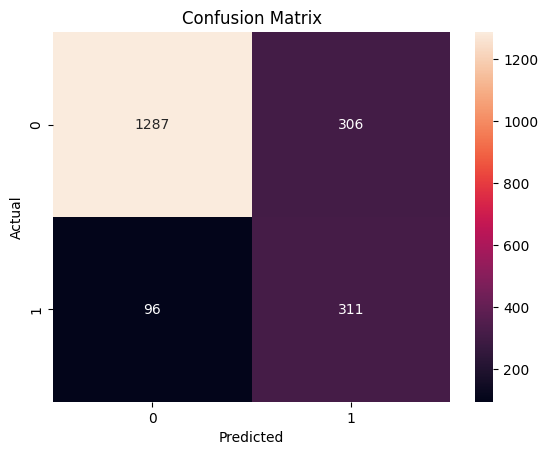

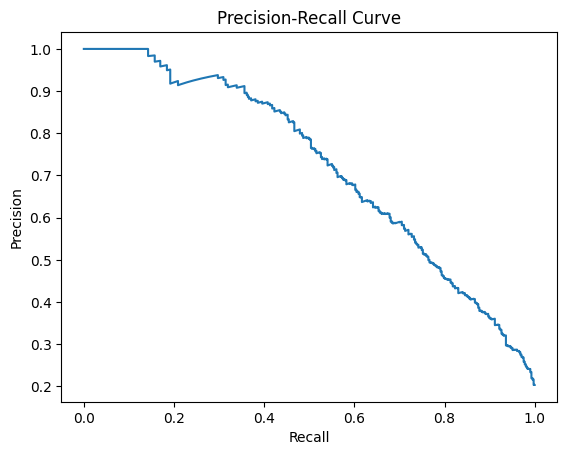

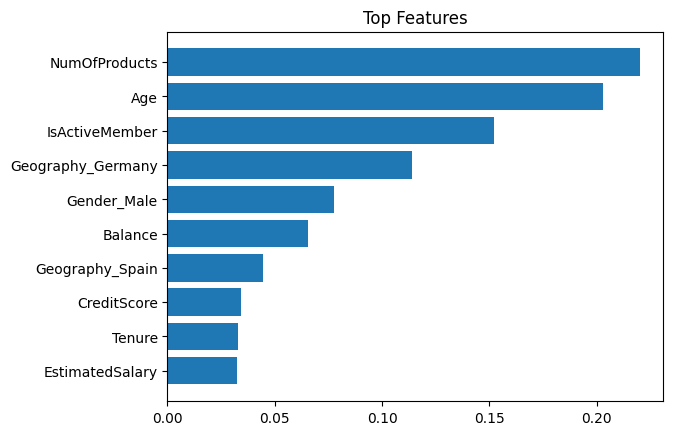


Model saved successfully!


In [2]:
# =========================
# 🚀 ULTRA OPTIMIZED CHURN PREDICTION (TOP 1%)
# =========================

# Install dependencies
!pip install kagglehub xgboost -q

# =========================
# 📥 1. LOAD DATASET
# =========================
import kagglehub
import os
import pandas as pd

path = kagglehub.dataset_download("shantanudhakadd/bank-customer-churn-prediction")
file_path = os.path.join(path, os.listdir(path)[0])

df = pd.read_csv(file_path)

print("Shape:", df.shape)

# =========================
# 🧹 2. CLEAN DATA
# =========================
drop_cols = ['RowNumber', 'CustomerId', 'Surname']
for col in drop_cols:
    if col in df.columns:
        df.drop(columns=col, inplace=True)

# Encode categorical
df = pd.get_dummies(df, drop_first=True)

# =========================
# 🎯 3. TARGET
# =========================
y = df['Exited']
X = df.drop(columns=['Exited'])

# =========================
# ⚖️ 4. HANDLE IMBALANCE (CRUCIAL)
# =========================
# Calculate class imbalance
neg, pos = y.value_counts()
scale_pos_weight = neg / pos

print("scale_pos_weight:", scale_pos_weight)

# =========================
# ✂️ 5. TRAIN-TEST SPLIT
# =========================
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# =========================
# ⚙️ 6. HYPERPARAMETER TUNING
# =========================
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV

xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    scale_pos_weight=scale_pos_weight,
    use_label_encoder=False
)

param_dist = {
    'n_estimators': [200, 300, 500],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.03, 0.05],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'gamma': [0, 0.1, 0.3],
    'min_child_weight': [1, 3, 5]
}

random_search = RandomizedSearchCV(
    xgb,
    param_distributions=param_dist,
    n_iter=15,
    scoring='roc_auc',
    cv=3,
    verbose=1,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

best_model = random_search.best_estimator_

print("Best Params:", random_search.best_params_)

# =========================
# 📊 7. EVALUATION
# =========================
from sklearn.metrics import roc_auc_score, classification_report

y_probs = best_model.predict_proba(X_test)[:, 1]
y_pred = best_model.predict(X_test)

auc = roc_auc_score(y_test, y_probs)

print("\nROC-AUC:", auc)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# =========================
# 📉 8. CONFUSION MATRIX
# =========================
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# =========================
# 📈 9. PRECISION-RECALL CURVE
# =========================
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_probs)

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

# =========================
# 🔍 10. FEATURE IMPORTANCE
# =========================
import numpy as np

importances = best_model.feature_importances_
indices = np.argsort(importances)[-10:]

plt.figure()
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
plt.title("Top Features")
plt.show()

# =========================
# 💾 11. SAVE MODEL
# =========================
import joblib

joblib.dump(best_model, "best_churn_model.pkl")

print("\nModel saved successfully!")